# Topic Modeling & Temporal Evolution — Archelec corpus

In [ ]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from archelec_topics.loader import load_corpus
from archelec_topics.description import column_overview, value_distribution, text_statistics, temporal_distribution
from archelec_topics.preprocessing import preprocess_corpus
from archelec_topics.models import LDATopicModel, NMFTopicModel
from archelec_topics.visualisation import plot_topic_words
from archelec_topics.evaluation import summarize_model
from archelec_topics.evaluation import sweep_n_topics

pd.set_option("display.max_columns", None)   # show all columns
plt.rcParams.update({                    # NeurIPS-style matplotlib settings
    # Figure
    "figure.figsize":    (6.5, 3.5),     # NeurIPS column width is ~5.5", full page ~6.75"
    "figure.dpi":        100,
    "savefig.dpi":       300,            # high DPI for crisp publication output
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.05,
    
    # Fonts — Times New Roman to match the NeurIPS LaTeX template
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":  "stix",         # serif math that matches Times
    
    # Sizes (NeurIPS uses 10pt body text)
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
    
    # Axes
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linestyle":     "-",
    "grid.linewidth":     0.4,
    
    # Ticks
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  3,
    "ytick.major.size":  3,
    
    # Lines & markers
    "lines.linewidth":   1.2,
    "lines.markersize":  4,
    
    # Legend
    "legend.frameon":    False,
    
    # Colors — colorblind-safe palette (Paul Tol's "muted")
    "axes.prop_cycle": plt.cycler(
        color=["#332288", "#117733", "#882255", "#88CCEE",
               "#DDCC77", "#CC6677", "#44AA99", "#AA4499"]
    ),
})

In [4]:
# Constant variables for the whole file

DATA_DIR = Path("./data")
METADATA_CSV = "archelect_search.csv"
TRANSCRIPTIONS_DIR = "arkindex_archelec/text_files"

## 1. The data : loading, pre-processing and analyzing

### 1.1 Load the full corpus with metadata

In [5]:
# Load the full corpus

df_full = load_corpus(
    metadata_csv   = DATA_DIR / METADATA_CSV,
    text_files_dir = DATA_DIR / TRANSCRIPTIONS_DIR,
)
print(df_full.shape)
df_full.head()

/Users/emmaleguay/Library/CloudStorage/OneDrive-HECParis/2025-2026-3A-ENSAE-MiE/S2/ML pour NLP/Archelec_NLP_topic_analysis/archelec_topics/loader.py:47: DtypeWarning: Columns (0: departement-nom, 1: departement-insee, 2: identifiant de circonscription, 3: pdf, 4: suppleant-nom, 5: suppleant-prenom, 6: suppleant-sexe, 7: suppleant-age, 8: suppleant-age-calcule, 9: suppleant-age-tranche, 10: suppleant-profession, 11: suppleant-mandat-en-cours, 12: suppleant-mandat-passe, 13: suppleant-associations, 14: suppleant-autres-statuts, 15: suppleant-soutien, 16: suppleant-liste, 17: suppleant-decorations) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(metadata_csv)


(21697, 43)


,id,text,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,identifiant de circonscription,images,pdf,ocr_url,titulaire-nom,titulaire-prenom,titulaire-sexe,titulaire-age,titulaire-age-calcule,titulaire-age-tranche,titulaire-profession,titulaire-mandat-en-cours,titulaire-mandat-passe,titulaire-associations,titulaire-autres-statuts,titulaire-soutien,titulaire-liste,titulaire-decorations,suppleant-nom,suppleant-prenom,suppleant-sexe,suppleant-age,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL175_L_1988_06_037_03_1_PF_03,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,1988-06-05,Ve République;Élections législatives;Assemblée...,"Élections législatives de 1988, Indre-et-Loire...",législatives,1.0,EL175,37,Indre-et-Loire,37 - Indre-et-Loire,3,https://ia801504.us.archive.org/2/items/EL175_...,https://ia801504.us.archive.org/2/items/EL175_...,https://ia801504.us.archive.org/2/items/EL175_...,Mora,Christiane,femme,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,député sortant,non mentionné,non mentionné,non mentionné,Majorité présidentielle pour la France unie,non,Boussiquet,Henri,homme,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,syndicat,non mentionné,non mentionné,Majorité présidentielle pour la France unie,non
1,EL177_L_1988_06_078_05_1_PF_01,ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988\n...,1988-06-05,Élections législatives;France;Ve République;As...,"Élections législatives de 1988, Yvelines - 78,...",législatives,1.0,EL177,78,Yvelines,78 - Yvelines (Seine-et-Oise),5,https://ia801807.us.archive.org/33/items/EL177...,https://ia801807.us.archive.org/33/items/EL177...,https://ia801807.us.archive.org/33/items/EL177...,Jonemann,Alain,homme,non mentionné,non mentionné,non mentionné,expert judiciaire,maire;conseiller général,conseiller régional,non mentionné,non mentionné,Rassemblement pour la République,Union du rassemblement et du centre,oui,Wetzel,Laurent,homme,non mentionné,non mentionné,non mentionné,professeur,conseiller municipal;conseiller général,non mentionné,non mentionné,non mentionné,Union pour la démocratie française,Union du rassemblement et du centre,non
2,EL175_L_1988_06_049_06_1_PF_04,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,1988-06-05,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1988, Maine-et-Loire...",législatives,1.0,EL175,49,Maine-et-Loire,49 - Maine-et-Loire,6,https://ia801809.us.archive.org/19/items/EL175...,https://ia801809.us.archive.org/19/items/EL175...,https://ia801809.us.archive.org/19/items/EL175...,Bordier,François,homme,non mentionné,non mentionné,non mentionné,enseignant,non mentionné,non mentionné,non mentionné,non mentionné,Parti socialiste,Majorité présidentielle pour la France unie,non,Palussiere,Victor,homme,non mentionné,non mentionné,non mentionné,non mentionné,conseiller municipal,non mentionné,non mentionné,non mentionné,Parti socialiste,Majorité présidentielle pour la France unie,non
3,EL175_L_1988_06_054_06_1_PF_05,"PARTI OUVRIER EUROPÉEN Siège : 19, rue Nollet,...",1988-06-05,Ve République;Élections législatives;France;As...,"Élections législatives de 1988, Meurthe-et-Mos...",législatives,1.0,EL175,54,Meurthe-et-Moselle,54 - Meurthe-et-Moselle,6,https://ia800806.us.archive.org/34/items/EL175...,https://ia800806.us.archive.org/34/items/EL175...,https://ia800806.us.archive.org/34/items/EL175...,non mentionné,non mentionné,non déterminé,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,Parti ouvrier européen,non mentionné,non,non mentionné,non mentionné,non déterminé,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,Parti ouvrier européen,non menti

### 1.2. Analysis of the corpus

In [6]:
# Column overview to understand the structure of the dataset and identify key variables for analysis

column_overview(df_full)

,column,dtype,n_non_null,n_unique,example
0,id,str,21697,21697,EL175_L_1988_06_037_03_1_PF_03
1,date,str,21167,11,1988-06-05
2,subject,str,21167,26,Ve République;Élections législatives;Assemblée...
3,title,str,21167,20969,"Élections législatives de 1988, Indre-et-Loire..."
4,contexte-election,str,21167,1,législatives
5,contexte-tour,float64,21167,2,1.0
6,cote,str,21167,30,EL175
7,departement,str,21167,106,37
8,departement-nom,str,21167,108,Indre-et-Loire
9,departement-insee,str,21167,106,37 - Indre-et-Loire


In [7]:
# Reduce DataFrame to relevant columns
keep_columns = [
    # Identifier and content
    "id",
    "text",
    
    # Archival metadata
    "subject",
    "title",
    "cote",
    
    # Temporal & geographic dimensions
    "date",
    "departement-nom",
    "departement-insee",
    "identifiant de circonscription",
    
    # Round of election
    "contexte-tour",
    
    # Candidate sociodemographic features
    "titulaire-sexe",
    "titulaire-age-tranche",
    "titulaire-profession",
    
    # Candidate political affiliation
    "titulaire-soutien",
    "titulaire-liste",
    
    # Candidate political experience
    "titulaire-mandat-en-cours",
    "titulaire-mandat-passe",
]

df = df_full[keep_columns].copy()

# Extract year from date for downstream temporal analyses
df["year"] = pd.to_datetime(df["date"], errors="coerce").dt.year
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"Reduced from {df_full.shape[1]} to {df.shape[1]} columns")
print(f"Year range: {df['year'].min():.0f}–{df['year'].max():.0f}")

Reduced from 43 to 18 columns
Year range: 1973–1993


In [8]:
# More detailed variable distributions on key columns

key_cols = ["date", "contexte-election", "contexte-tour", "titulaire-soutien", "titulaire-liste", "titulaire-sexe", "titulaire-age-tranche", "titulaire-profession", "titulaire-mandat-en-cours", "titulaire-mandat-passe"]
for col in key_cols:
    print(f"\n=== {col} ===")
    print(value_distribution(df_full, col, top_n=20))


=== date ===
            n_documents  proportion
date                               
1993-03-21         4872    0.224547
1978-03-12         4007    0.184680
1973-03-04         2922    0.134673
1988-06-05         2685    0.123750
1981-06-14         2468    0.113748
1993-03-28          965    0.044476
1973-03-11          921    0.042448
1988-06-12          854    0.039360
1978-03-19          817    0.037655
1981-06-21          653    0.030096
NaN                 530    0.024427
1978-03-01            3    0.000138

=== contexte-election ===
                   n_documents  proportion
contexte-election                         
législatives             21167    0.975573
NaN                        530    0.024427

=== contexte-tour ===
               n_documents  proportion
contexte-tour                         
1.0                  16957    0.781537
2.0                   4210    0.194036
NaN                    530    0.024427

=== titulaire-soutien ===
                                      

### Corpus Description

The full Archelec corpus consists of **21,697 OCR'd political manifestos** from
French legislative elections, joined with metadata exported from the Archelec
Sciences Po explorer. The metadata covers **only legislative elections**
(`contexte-election` is constant), so the temporal evolution analysis will
contrast different legislative cycles rather than different election types.

#### Quality of the join

530 transcriptions (~2.4%) have no corresponding metadata in the CSV. These
are likely documents that were OCR'd but not yet catalogued, or files with
identifier mismatches. We discard them, leaving **21,167 documents** with
both text and metadata.

#### Structure of the corpus

After filtering, the corpus covers **11 distinct election dates** spanning
several decades of the Ve Republic. Each document corresponds to one
candidate (`titulaire`) running in a specific *circonscription*. About
**78%** of documents are first-round manifestos and **19%** are second-round
manifestos.

#### Coverage of candidate metadata

Coverage varies considerably across metadata fields:

- **Sex** is reliably recorded (98% non-missing) — 84% men, 10% women,
  4% undetermined. Female representation is low, as expected from the
  sociology of French legislative candidates over the period.
- **Political affiliation** (`titulaire-soutien`) is missing for 18% of
  candidates. The 1,523 unique values are inflated by alliance strings
  (e.g., *"RPR;UDF"*); the underlying distinct parties are far fewer
  and will need to be normalized for cross-tabulations.
- **Profession** is missing for 44% of candidates, which restricts any
  topic × profession analysis to roughly half of the corpus. Among
  documented professions, liberal professions (lawyers, doctors,
  engineers) and teaching dominate, consistent with known patterns of
  candidate sociology.

These coverage gaps shape what kind of cross-analyses are statistically
meaningful and are reported alongside results in later sections.

In [9]:
# Implement some fixes

# Drop rows where text is missing (the only column that really matters)
before = len(df)
df = df.dropna(subset=["text"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows without text, {len(df)} remaining")

# Fix the 1978 anomaly: 3 dates instead of 2 (1st and 2nd round)
mask = df["date"] == "1978-03-01"
print(f"Fixing {mask.sum()} rows with date 1978-03-01")
df.loc[mask, "date"] = "1978-03-12"

# Replace 'non mentionné' with NaN across all string columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].replace("non mentionné", pd.NA)

# Right format for integer variables
df["contexte-tour"] = df["contexte-tour"].astype("Int64")
df["identifiant de circonscription"] = pd.to_numeric(
    df["identifiant de circonscription"], errors="coerce"
).astype("Int64")

# Reput the date column in datetime format after fixing the 1978 anomaly
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date
df["year"] = pd.to_datetime(df["date"], errors="coerce").dt.year

# Create dummy variables for current and past mandates
df["dummy_titulaire_mandat_en_cours"] = df["titulaire-mandat-en-cours"].notna().astype(int)
df["dummy_titulaire_mandat_passe"]    = df["titulaire-mandat-passe"].notna().astype(int)

print(df[["dummy_titulaire_mandat_en_cours", "dummy_titulaire_mandat_passe"]].sum())
df.head(5)

Dropped 0 rows without text, 21697 remaining
Fixing 3 rows with date 1978-03-01
dummy_titulaire_mandat_en_cours    8759
dummy_titulaire_mandat_passe       4349
dtype: int64


/var/folders/wg/135c97bj1s97wh3d6qqx1vgw0000gn/T/ipykernel_31119/3395867077.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,id,text,subject,title,cote,date,departement-nom,departement-insee,identifiant de circonscription,contexte-tour,titulaire-sexe,titulaire-age-tranche,titulaire-profession,titulaire-soutien,titulaire-liste,titulaire-mandat-en-cours,titulaire-mandat-passe,year,dummy_titulaire_mandat_en_cours,dummy_titulaire_mandat_passe
0,EL175_L_1988_06_037_03_1_PF_03,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,Ve République;Élections législatives;Assemblée...,"Élections législatives de 1988, Indre-et-Loire...",EL175,1988-06-05,Indre-et-Loire,37 - Indre-et-Loire,3,1,femme,NaN,NaN,NaN,Majorité présidentielle pour la France unie,NaN,député sortant,1988.0,0,1
1,EL177_L_1988_06_078_05_1_PF_01,ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988\n...,Élections législatives;France;Ve République;As...,"Élections législatives de 1988, Yvelines - 78,...",EL177,1988-06-05,Yvelines,78 - Yvelines (Seine-et-Oise),5,1,homme,NaN,expert judiciaire,Rassemblement pour la République,Union du rassemblement et du centre,maire;conseiller général,conseiller régional,1988.0,1,1
2,EL175_L_1988_06_049_06_1_PF_04,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE\nA...,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1988, Maine-et-Loire...",EL175,1988-06-05,Maine-et-Loire,49 - Maine-et-Loire,6,1,homme,NaN,enseignant,Parti socialiste,Majorité présidentielle pour la France unie,NaN,NaN,1988.0,0,0
3,EL175_L_1988_06_054_06_1_PF_05,"PARTI OUVRIER EUROPÉEN Siège : 19, rue Nollet,...",Ve République;Élections législatives;France;As...,"Élections législatives de 1988, Meurthe-et-Mos...",EL175,1988-06-05,Meurthe-et-Moselle,54 - Meurthe-et-Moselle,6,1,non déterminé,NaN,NaN,Parti ouvrier européen,NaN,NaN,NaN,1988.0,0,0
4,EL177_L_1988_06_094_05_1_PF_06,"PARTI OUVRIER EUROPÉEN Siège : 19, rue Nollet,...",France;Élections législatives;Assemblée Nation...,"Élections législatives de 1988, Val-de-Marne -...",EL177,1988-06-05,Val-de-Marne,94 - Val-de-Marne,5,1,non déterminé,NaN,NaN,Parti ouvrier européen,NaN,NaN,NaN,1988.0,0,0


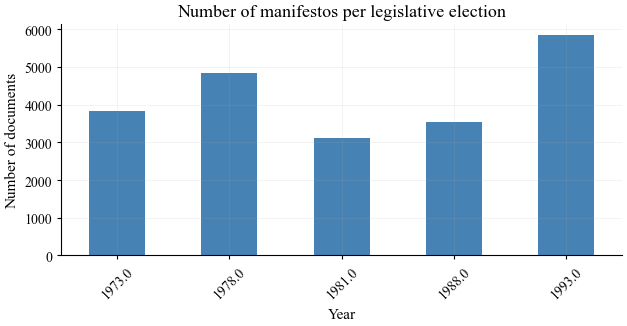

In [10]:
# Documents per legislative election year

docs_per_year = df["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6.5, 3.5))
docs_per_year.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of manifestos per legislative election")
ax.set_xlabel("Year")
ax.set_ylabel("Number of documents")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/01_docs_per_year.png", dpi=150)
plt.show()

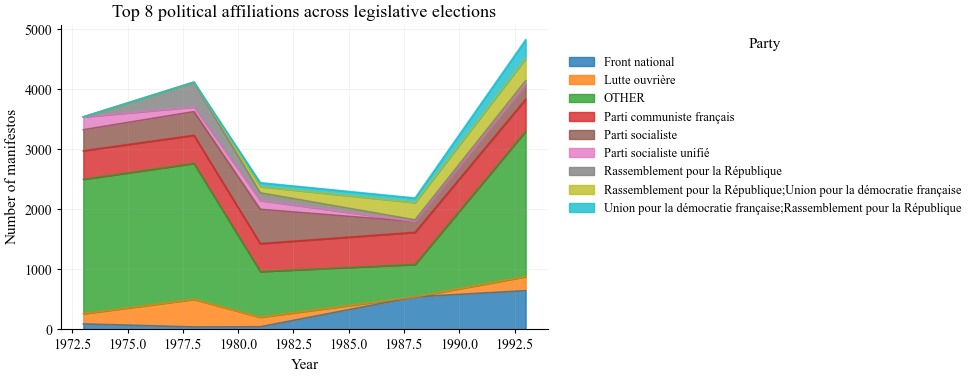

In [11]:
# Top political affiliations across time (stacked area)
party_over_time = temporal_distribution(df, group_col="titulaire-soutien", top_n=8)

fig, ax = plt.subplots(figsize=(10, 4))
party_over_time.plot(kind="area", stacked=True, ax=ax, alpha=0.8, colormap="tab10")
ax.set_title("Top 8 political affiliations across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of manifestos")
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("charts/02_parties_over_time.png", dpi=150)
plt.show()

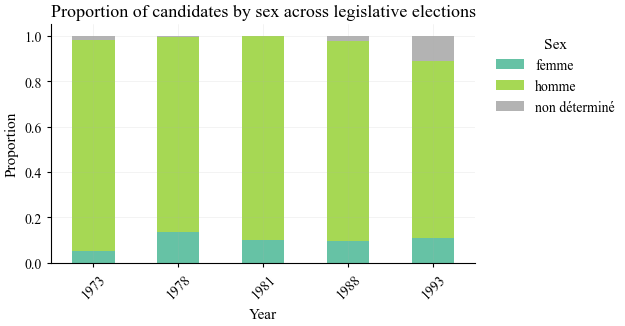

In [12]:
# Sex distribution over time — illustrates the slow feminization of candidacies
sex_over_time = temporal_distribution(df, group_col="titulaire-sexe")

# Convert to proportions per year
sex_props = sex_over_time.div(sex_over_time.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
sex_props.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Proportion of candidates by sex across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion")
ax.legend(title="Sex", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/03_sex_over_time.png", dpi=150)
plt.show()

            total         mean  median          std  min    max
n_chars  95057525  4381.136793  3943.0  2355.164392   63  50611
n_words  15167205   699.046181   626.0   377.941159    9   8255


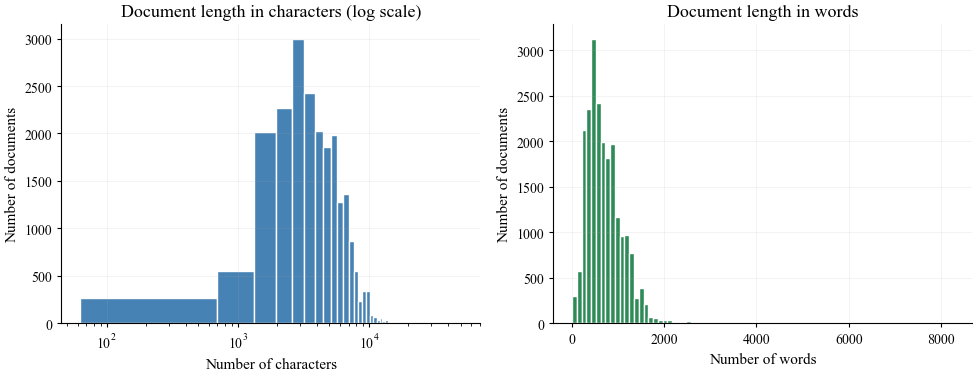

In [13]:
# Document length distribution
text_stats_summary = text_statistics(df)
print(text_stats_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Char length distribution (log scale to spot OCR failures)
df["text"].str.len().hist(bins=80, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Document length in characters (log scale)")
axes[0].set_xlabel("Number of characters")
axes[0].set_ylabel("Number of documents")

# Word length distribution
df["text"].str.split().str.len().hist(bins=80, ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_title("Document length in words")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Number of documents")

plt.tight_layout()
plt.savefig("charts/04_text_lengths.png", dpi=150)
plt.show()

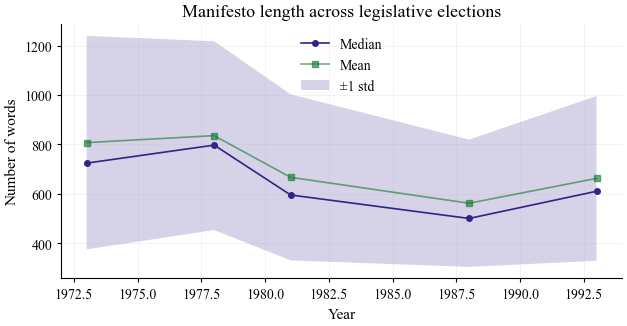

In [14]:
# Median document length over time — has OCR quality improved? Have manifestos changed in style?
length_by_year = (
    df.assign(n_words=df["text"].str.split().str.len())
    .groupby("year")["n_words"]
    .agg(["median", "mean", "std"])
)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(length_by_year.index, length_by_year["median"], marker="o", label="Median")
ax.plot(length_by_year.index, length_by_year["mean"],   marker="s", label="Mean", alpha=0.6)
ax.fill_between(
    length_by_year.index,
    length_by_year["mean"] - length_by_year["std"],
    length_by_year["mean"] + length_by_year["std"],
    alpha=0.2, label="±1 std"
)
ax.set_title("Manifesto length across legislative elections")
ax.set_xlabel("Year")
ax.set_ylabel("Number of words")
ax.legend()
plt.tight_layout()
plt.savefig("charts/05_length_over_time.png", dpi=150)
plt.show()

### Visual exploration of the corpus

The five plots above provide a first portrait of the working corpus. Several
observations directly inform the modeling choices made in the rest of the report.

#### Volume of manifestos per election

The number of archived manifestos varies substantially across the five
legislative elections covered (1973, 1978, 1981, 1988, 1993), ranging from
roughly 3,100 documents in 1981 to about 5,800 in 1993. This imbalance has two
implications. First, the time slices used for the Dynamic Topic Model will not
be of equal size, which is acceptable as long as the slice ordering is
respected. Second, any per-year average should be interpreted in light of these
differences in coverage rather than as a direct measure of political activity.

#### Political affiliations across time

The stacked area plot of the top eight `titulaire-soutien` values reveals the
expected shifts of the French political landscape over the period. The Front
National appears only from the 1980s onward, mirroring its historical rise.
Coalition labels (e.g., *RPR;UDF*, *UDF;RPR*) appear and disappear as
right-wing alliances reorganize. A large *OTHER* category remains visible
throughout, reflecting the long tail of small parties and independent
candidates. The plot also exposes the orthographic noise we noted earlier:
*RPR;UDF* and *UDF;RPR* are recorded as distinct labels even though they
denote the same coalition. A normalization step on party labels will be
necessary before any party-level topic analysis.

#### Sex composition accross time

Female candidacies remain a small minority across all five elections,
oscillating between roughly 5% (1973) and 14% (1978), with no clear monotonic
trend over the period. The 1993 election introduces a noticeable share of
*non-déterminé* cases, which reflects metadata quality rather than a real
sociological change. This low level of female representation makes any
finely-grained sex × topic analysis statistically tenuous, and we will treat
sex as a secondary covariate rather than a primary axis of analysis.

#### Document-length distribution accross time

The character-length histogram (left, log scale) shows a small left-tail of
documents below ~500 characters that is well separated from the bulk of the
distribution centered around 2,000–5,000 characters. This left-tail is most
likely caused by OCR failures (very partial transcriptions) and motivates a
minimum-length filter before topic modeling. The word-length histogram
(right, linear scale) confirms a right-skewed distribution: the median
manifesto contains a few hundred words, while a small number of documents
exceed 2,000 words.

#### Manifesto length over time

Median and mean document lengths drop noticeably between 1978 (~800 words)
and 1988 (~550 words), then partially recover in 1993. This downward trend
could reflect a real stylistic evolution toward more concise manifestos, but
it is equally plausible that variations in OCR quality across decades
contribute to it. We do not attempt to disentangle these two hypotheses here,
but flag the trend as a potential confounder when interpreting topic
prevalence over time.

In [ ]:
# Implement some more fixes based on the above analyses

# TO DO : drop some documents that are too short (probably OCR failures) 
# and some that are too long (probably compilations of multiple manifestos) ??

### 1.3 Processing the text data

The preprocessing pipeline follows the recipe outlined in the course
(*Topic Modeling*) and consists of:

1. **OCR cleanup** — removing recurring archival headers (Sciences Po,
   République française, Élections législatives), mending hyphenated 
   line breaks, dropping non-letters and isolated single characters.
2. **Lemmatization** — using `spaCy`'s French model 
   (`fr_core_news_md`) with the parser and NER components disabled for speed.
3. **POS filtering** — keeping only content words (nouns, proper nouns,
   adjectives, verbs).
4. **Stopword removal** — combining spaCy's default French stopword list
   with a domain-specific list (generic electoral vocabulary, formulas of
   address, month names) iteratively refined by inspection of early model
   outputs.

The result is a list of lemmatized tokens per document, persisted to
`data/processed/tokens.pkl` for reuse across sessions.

In [17]:
# Preprocess the corpus for topic modeling
# This takes ~10-15 minutes on the 21k documents.
# We pickle the result so we don't have to redo this in future sessions.

# Make sure the output directory exists
Path("data/processed").mkdir(parents=True, exist_ok=True)

# Run preprocessing on the entire corpus
tokens = preprocess_corpus(df["text"].tolist())

# Save to disk
with open("data/processed/tokens.pkl", "wb") as f:
    pickle.dump(tokens, f)

print(f"Preprocessed {len(tokens)} documents")
print(f"Vocabulary size (raw): {len(set(t for doc in tokens for t in doc))}")
print(f"Sample tokens (first doc): {tokens[0][:30]}")

Lemmatizing: 100%|██████████| 21697/21697 [14:14<00:00, 25.38it/s]


Preprocessed 21697 documents
Vocabulary size (raw): 105738
Sample tokens (first doc): ['france', 'uni', 'christiane', 'mora', 'henri', 'boussiquet', 'suppleer', 'majorite', 'presidentiell', 'france', 'uni', 'indre', 'loire', 'mademoiselle', 'femme', 'homme', 'renouveler', 'confiance', 'président', 'république', 'françois', 'mitterrand', 'victoire', 'france', 'rassembler', 'solidaire', 'france', 'jeunesse', 'soucieux', 'famille']


In [18]:
# Inspect preprocessing results on a few sampled documents
import random

random.seed(42)
sample_indices = random.sample(range(len(df)), 5)

for idx in sample_indices:
    print("=" * 80)
    print(f"Document {idx}")
    print(f"  id:      {df.iloc[idx]['id']}")
    print(f"  year:    {df.iloc[idx]['year']}")
    print(f"  party:   {df.iloc[idx]['titulaire-soutien']}")
    print(f"  n_chars: {len(df.iloc[idx]['text'])}")
    print(f"  n_tokens: {len(tokens[idx])}")
    
    print("\n--- ORIGINAL TEXT (first 600 chars) ---")
    print(df.iloc[idx]["text"][:600])
    
    print("\n--- TOKENS (first 50) ---")
    print(tokens[idx][:50])
    
    print("\n--- TOKENS (joined as text, first 600 chars) ---")
    joined = " ".join(tokens[idx])
    print(joined[:600])
    print()

Document 20952
  id:      EL105_L_1978_03_069_11_1_PF_09
  year:    1978.0
  party:   Organisation communiste bolchevik
  n_chars: 6020
  n_tokens: 425

--- ORIGINAL TEXT (first 600 chars) ---
DÉPARTEMENT DU RHONE - | |eme CIRCONSCRIPTION
Élections Législatives du 12 Mars 1978
ORGANISATION COMMUNISTE BOLCHEVIK
Camarades ouvriers et ouvrières ! Electeurs et électrices de la 11e circonscription !
L'Organisation communiste bolchevik m'a choisi pour la représenter aux législatives de mars 1978.
Le but de ma candidature est simple : mettre à profit les élections organisées sous le joug des capitalistes, pour faire connaître aux travailleurs exploités notre programme révolutionnaire, pour les appeler à la lutte révolutionnaire contre le capitalisme, pour son renversement.
L'organisation c

--- TOKENS (first 50) ---
['département', 'rhone', 'organisation', 'communiste', 'camarade', 'ouvrier', 'ouvrier', 'electeur', 'électrice', 'organisation', 'communiste', 'choisir', 'représenter', 'législat

In [19]:
# Search for specific tokens that should have been removed
suspicious_tokens = ["sciences", "po", "cevipof", "fonds", "république", "législatif"]
for tok in suspicious_tokens:
    n_docs_with = sum(1 for doc in tokens if tok in doc)
    print(f"  '{tok}' appears in {n_docs_with} documents ({100*n_docs_with/len(tokens):.1f}%)")

  'sciences' appears in 0 documents (0.0%)
  'po' appears in 0 documents (0.0%)
  'cevipof' appears in 2 documents (0.0%)
  'fonds' appears in 1303 documents (6.0%)
  'république' appears in 6471 documents (29.8%)
  'législatif' appears in 818 documents (3.8%)


In [20]:
# Most frequent tokens overall — sanity check
from collections import Counter

all_tokens = [tok for doc in tokens for tok in doc]
counter = Counter(all_tokens)
print("Top 30 most frequent tokens:")
for tok, count in counter.most_common(30):
    print(f"  {tok:20s} {count:6d}")

print(f"\nTotal vocabulary size: {len(counter)}")
print(f"Tokens appearing only once: {sum(1 for c in counter.values() if c == 1)}")

Top 30 most frequent tokens:
  pouvoir               57257
  politique             50898
  faire                 47914
  gauche                40628
  france                38916
  national              38765
  social                37853
  parti                 36538
  devoir                34296
  travailleur           33896
  communiste            29765
  socialiste            28905
  vouloir               28507
  falloir               28026
  vie                   27144
  majorité              25831
  emploi                25489
  pays                  24945
  homme                 24669
  droite                23717
  travail               23265
  suppléant             23023
  grand                 22407
  programme             20420
  voir                  20334
  liberté               19607
  droit                 19163
  gouvernement          19102
  jean                  18711
  maire                 18679

Total vocabulary size: 105738
Tokens appearing only once: 48321


In [23]:
# Document frequency check — find tokens that appear in most documents
from collections import defaultdict

doc_freq = defaultdict(int)
for doc in tokens:
    for tok in set(doc):  # set() to count once per document
        doc_freq[tok] += 1

# Tokens appearing in >70% of documents are candidates for stopwords
high_freq = {tok: count for tok, count in doc_freq.items() if count > 0.5 * len(tokens)}
print(f"Tokens appearing in >70% of documents ({len(high_freq)}):")
for tok, count in sorted(high_freq.items(), key=lambda x: -x[1]):
    print(f"  {tok:20s} {count} ({100*count/len(tokens):.0f}%)")

Tokens appearing in >70% of documents (21):
  faire                16355 (75%)
  politique            16164 (74%)
  pouvoir              16091 (74%)
  social               15227 (70%)
  france               14843 (68%)
  suppléant            14620 (67%)
  voir                 14245 (66%)
  national             14063 (65%)
  pays                 13169 (61%)
  vouloir              12565 (58%)
  devoir               12503 (58%)
  parti                12389 (57%)
  emploi               12331 (57%)
  vie                  11862 (55%)
  homme                11768 (54%)
  travail              11749 (54%)
  grand                11390 (52%)
  socialiste           11227 (52%)
  majorité             11055 (51%)
  falloir              10940 (50%)
  gauche               10868 (50%)


In [32]:
# %% Token frequency analysis: total occurrences AND document frequency

# Total occurrences across the whole corpus
total_count = Counter()
for doc in tokens:
    total_count.update(doc)

# Document frequency (how many docs contain the token at least once)
doc_freq = defaultdict(int)
for doc in tokens:
    for tok in set(doc):
        doc_freq[tok] += 1

# Build a single DataFrame for inspection
n_docs = len(tokens)
freq_df = pd.DataFrame({
    "token":      list(total_count.keys()),
    "total":      [total_count[t] for t in total_count],
    "n_docs":     [doc_freq[t]    for t in total_count],
    "doc_pct":    [100 * doc_freq[t] / n_docs for t in total_count],
})

# Sort by total frequency and inspect the top 100
freq_df = freq_df.sort_values("total", ascending=False).reset_index(drop=True)
print(freq_df.head(100))

# Save it for offline review
freq_df.to_csv("data/processed/token_frequencies.csv", index=False)

        token  total  n_docs    doc_pct
0     pouvoir  57257   16091  74.162327
1   politique  50898   16164  74.498779
2       faire  47914   16355  75.379085
3      gauche  40628   10868  50.089874
4      france  38916   14843  68.410379
..        ...    ...     ...        ...
95   économie   8922    6265  28.874960
96     ancien   8872    5842  26.925381
97      créer   8793    6285  28.967138
98      front   8782    2842  13.098585
99   suffrage   8766    6386  29.432640

[100 rows x 4 columns]


In [ ]:
# TODO: put these analyses in a/several function(s) to clean here

## 2. First topic analysis : LDA and NMF

In [35]:
lda = LDATopicModel(n_topics=20, no_below=10, no_above=0.5, keep_n=15000)
lda.fit(tokens)

# Print topics
for k, words in enumerate(lda.get_top_words(n_words=12)):
    print(f"Topic {k:2d}: {' | '.join(words)}")

# Summary
summarize_model(lda, tokens)

Topic  0: président | marier | conseiller | enfant | jean | maire | membre | municipal | conseil | général | régional | vice
Topic  1: environnement | chômage | monde | solidarité | donner | formation | citoyen | loi | public | démocratie | assemblée | entente
Topic  2: accepter | europe | renne | vilain | version | ille | truquer | vosge | production | hervé | sortir | financier
Topic  3: droit | programme | femme | travailleur | commun | salaire | changer | mesure | vivre | loi | liberté | proposer
Topic  4: communiste | droite | changement | union | gouvernement | commun | programme | changer | moyen | force | victoire | austérité
Topic  5: marchai | ouvrier | lutte | jean | bretagne | progrès | breton | méfiance | hostilité | froid | employer | tour
Topic  6: rpr | udf | front | avenir | force | confiance | suppression | populaire | antisocialiste | conviction | liste | électeur
Topic  7: die | partei | für | eine | hlen | linken | programm | halt | arbeiter | leben | programme | g

{'model': 'LDATopicModel',
 'n_topics': 20,
 'coherence_cv': 0.5540964146527574,
 'diversity': 0.692,
 'perplexity': 2972.1718150231186}

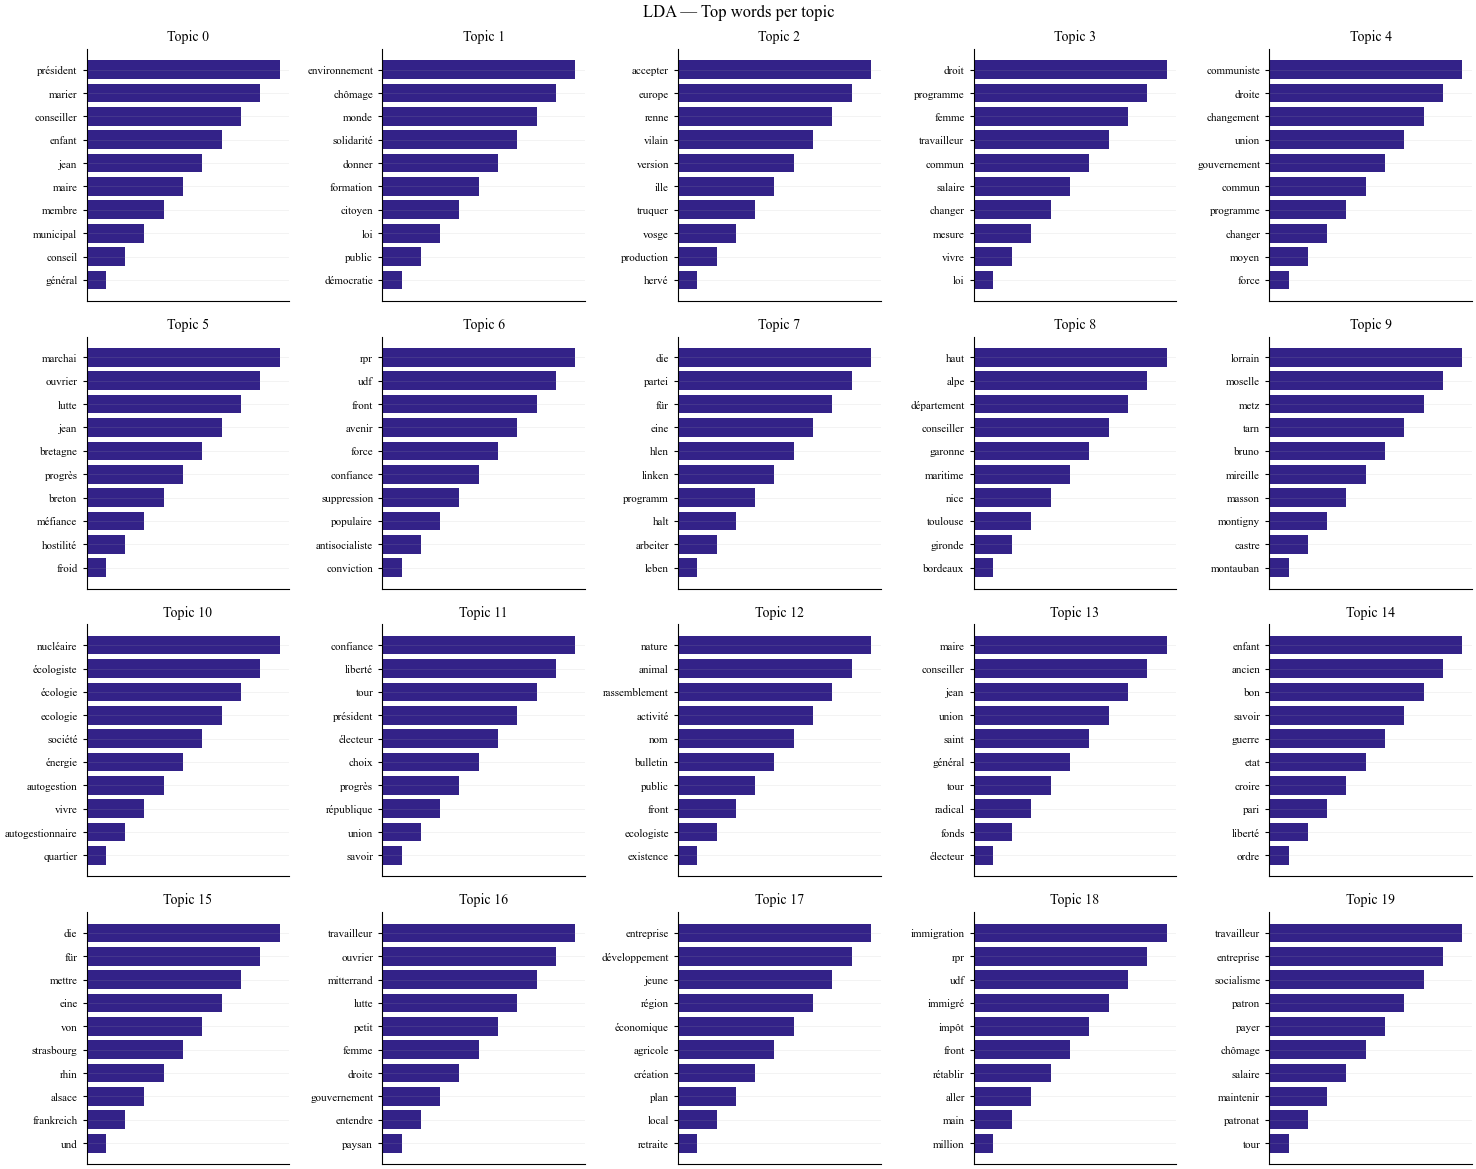

In [37]:
# LDA topic visualization (bar chart per topic)

plot_topic_words(lda.get_top_words(10), "LDA — Top words per topic")
plt.savefig("charts/06_lda_topics.png", dpi=200, bbox_inches="tight")
plt.show()

In [38]:
nmf = NMFTopicModel(n_topics=20, max_features=15000)
nmf.fit(tokens)

for k, words in enumerate(nmf.get_top_words(12)):
    print(f"Topic {k:2d}: {' | '.join(words)}")

summarize_model(nmf, tokens)

Topic  0: développement | entreprise | économique | région | droit | liberté | local | rural | jeune | service | retraite | plan
Topic  1: travailleur | mitterrand | ouvrier | petit | femme | marchai | entendre | lutte | bombe | atomique | droite | promettre
Topic  2: animal | nature | ecologiste | existence | rassemblement | bulletin | nom | activité | ruffi | documenta | corrida | compléte
Topic  3: front | udf | rpr | vif | liste | conviction | suppression | force | avenir | populaire | lepen | payent
Topic  4: udf | rpr | immigration | immigré | rétablir | impôt | carte | sauver | front | nationalité | supprimer | million
Topic  5: patron | patronat | payer | maintenir | sacrifice | jeter | vendre | travailleur | bourgeoisie | bénéfice | entreprise | banque
Topic  6: écologie | entente | ecologiste | vert | écologiste | ecologie | generation | environnement | génération | humain | chance | planète
Topic  7: dimanche | tour | maire | électeur | général | conseiller | jean | confianc

{'model': 'NMFTopicModel',
 'n_topics': 20,
 'coherence_cv': 0.6788567518805655,
 'diversity': 0.81,
 'reconstruction_err': 129.7164600521477}

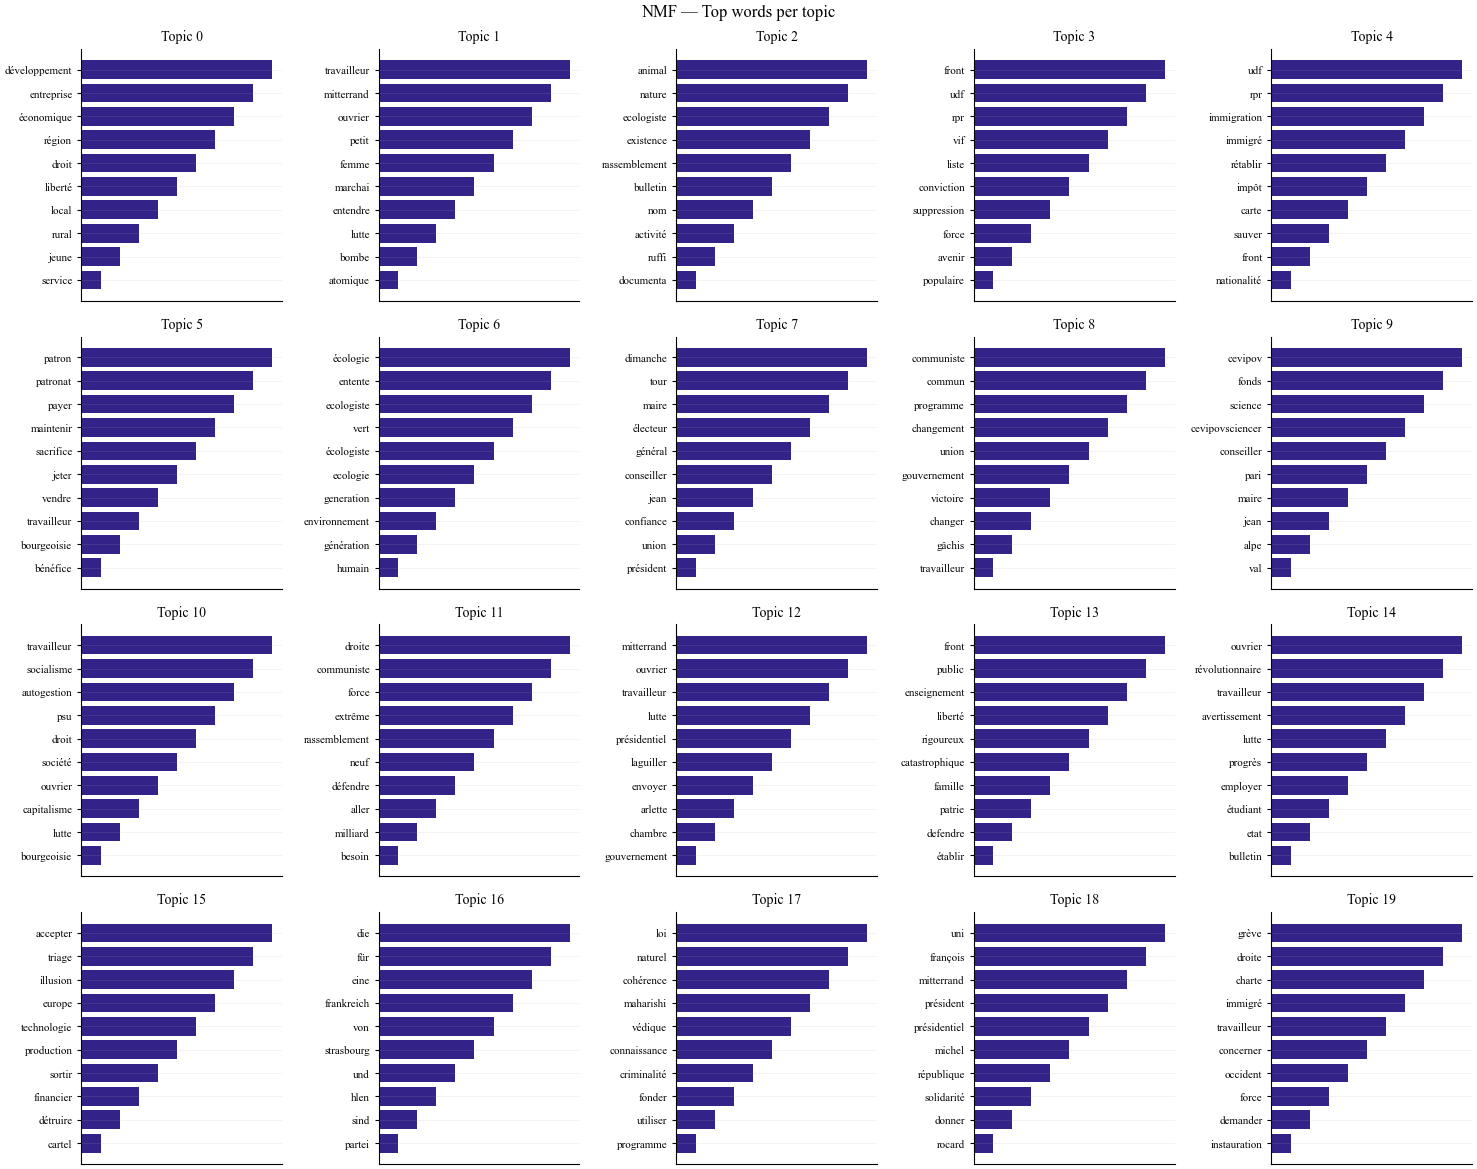

In [39]:
# %% NMF topic visualization
plot_topic_words(nmf.get_top_words(10), "NMF — Top words per topic")
plt.savefig("charts/07_nmf_topics.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Hyperparameter sweep on K for LDA and NMF

# Grid of K values to evaluate
K_GRID = [5, 10, 15, 20, 25, 30, 40, 50]

# LDA sweep
lda_sweep = sweep_n_topics(
    model_factory   = lambda k: LDATopicModel(
        n_topics    = k,
        no_below    = 10,
        no_above    = 0.5,
        keep_n      = 15000,
        passes      = 10,           
        random_state= 42,
    ),
    n_topics_grid   = K_GRID,
    documents       = tokens,
    tokenized_texts = tokens,
)

print(lda_sweep)
lda_sweep.to_csv("data/processed/lda_sweep.csv", index=False)

# %% NMF sweep

nmf_sweep = sweep_n_topics(
    model_factory   = lambda k: NMFTopicModel(
        n_topics    = k,
        max_features= 15000,
        min_df      = 10,
        max_df      = 0.5,
        random_state= 42,
    ),
    n_topics_grid   = K_GRID,
    documents       = tokens,
    tokenized_texts = tokens,
)

print(nmf_sweep)
nmf_sweep.to_csv("data/processed/nmf_sweep.csv", index=False)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Coherence
axes[0].plot(lda_sweep["n_topics"], lda_sweep["coherence_cv"], marker="o", label="LDA")
axes[0].plot(nmf_sweep["n_topics"], nmf_sweep["coherence_cv"], marker="s", label="NMF")
axes[0].set_xlabel("Number of topics K")
axes[0].set_ylabel("Cv coherence")
axes[0].set_title("Topic coherence vs K")
axes[0].legend()

# Diversity
axes[1].plot(lda_sweep["n_topics"], lda_sweep["diversity"], marker="o", label="LDA")
axes[1].plot(nmf_sweep["n_topics"], nmf_sweep["diversity"], marker="s", label="NMF")
axes[1].set_xlabel("Number of topics K")
axes[1].set_ylabel("Topic diversity")
axes[1].set_title("Topic diversity vs K")
axes[1].legend()

plt.tight_layout()
plt.savefig("charts/sweep_results.png", dpi=200, bbox_inches="tight")
plt.show()

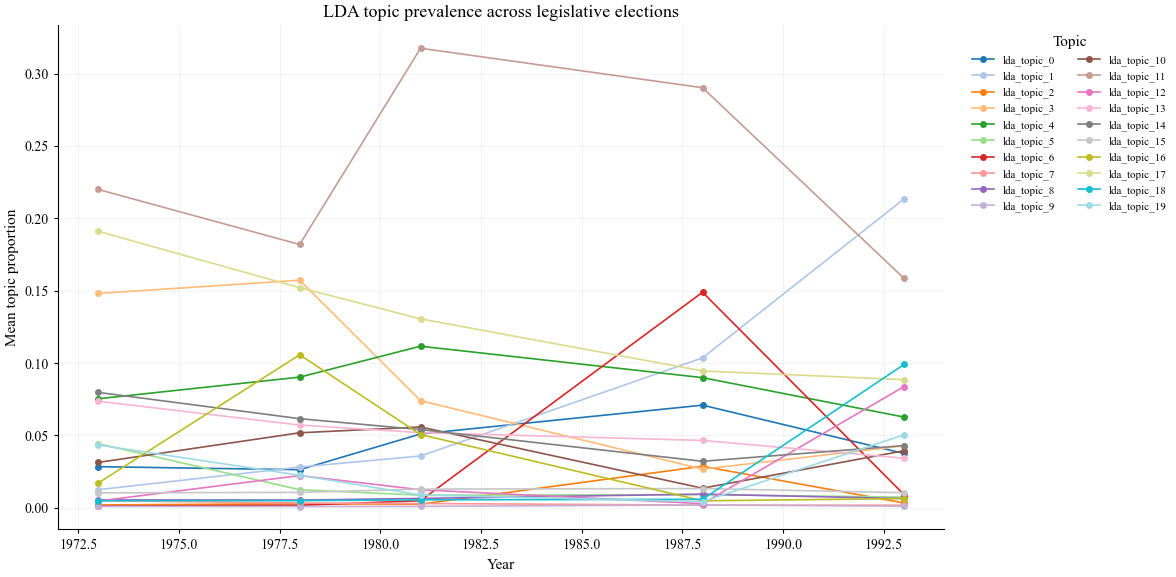

In [ ]:
# Topic prevalence over time (post-hoc temporal analysis on LDA)
doc_topic_lda = lda.get_doc_topic_matrix()
for k in range(lda.n_topics):
    df[f"lda_topic_{k}"] = doc_topic_lda[:, k]

prevalence_by_year = df.groupby("year")[[f"lda_topic_{k}" for k in range(lda.n_topics)]].mean()

fig, ax = plt.subplots(figsize=(12, 6))
prevalence_by_year.plot(kind="line", ax=ax, marker="o", colormap="tab20")
ax.set_title("LDA topic prevalence across legislative elections")
ax.set_ylabel("Mean topic proportion")
ax.set_xlabel("Year")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("charts/lda_topic_evolution.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# TODO: add method topic prevalence overtime to LDA and NMF classes